# Static XAS — shot-resolved photon energy
Load per-shot (VLS, GMD) data produced by `compute_static_xas.py`.
Instead of using only the nominal step-motor photon energy, we assign each shot a **photon-energy proxy** from the centre-of-mass (COM) of its VLS spectrum, rounded to the nearest pixel integer. This shot-resolved proxy lets us sort the data more finely and increases the effective spectral resolution compared with nominal-energy binning alone.

**Background subtraction (done by `compute_static_xas.py` before writing the H5)**:
1. Per-train baseline: non-signal bunches (`BG_BUNCH_RANGE = 50–100`) subtracted per train.
2. Per-section closed-shutter reference: mean VLS of the preceding closed-shutter block is subtracted from each open-shutter section.

Both stages can leave negative pixel values. We clip to non-negative only for the COM, while keeping `A_valid` unmodified for downstream averaging.

Workflow:
1. Flatten all shots over `N_E` → `(N_shots_total, n_pixels)`.
2. Compute per-shot VLS COM (non-negative weights) → round to nearest pixel → proxy energy.
3. Bin shots by `(proxy_energy, GMD bin)`.
4. Make the same diagnostic plots with the proxy-pixel axis instead of nominal eV.

In [100]:
import sys
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
%matplotlib inline
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')
sys.path.insert(0, str(repo_root / 'analysis' / 'scripts'))
import config as path_config


## Config

In [131]:
RUN_NO   = 58793
INPUT_H5 = Path(path_config.COMBINED_DIR).parent / 'xas_static' / f'run{RUN_NO}_static_xas.h5'
# GMD bin edges (uJ).
GMD_EDGES = np.array([0.0,1.6, 3.2, 6.4, 12.8])
# VLS intensity threshold (per shot peak).
# Shots with max(VLS over pixels) < VLS_INTENSITY_THRESHOLD are removed.
# Set to None to disable this filter.
VLS_INTENSITY_THRESHOLD = 1000

## Load data

In [102]:
with h5py.File(INPUT_H5, 'r') as f:
    vls              = f['vls'][...]              # (N_E, N_shots_max, n_pixels)
    gmd              = f['gmd'][...]              # (N_E, N_shots_max)
    n_shots          = f['n_shots'][...]          # (N_E,)
    nominal_energies = f['nominal_energies'][...]  # (N_E,)  kept for reference
    vls_pixels       = f['vls_pixels'][...]        # (n_pixels,) pixel indices
    attrs            = dict(f.attrs)

N_E, N_shots_max, n_pixels = vls.shape
print(f'file       : {INPUT_H5}')
print(f'run        : {attrs.get("run_no")}')
print(f'shape      : N_E={N_E}, N_shots_max={N_shots_max}, n_pixels={n_pixels}')
print(f'total shots: {int(n_shots.sum())}')
print(f'VLS ROI    : {attrs.get("vls_crop_roi")}')

file       : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/run58793_static_xas.h5
run        : 58793
shape      : N_E=31, N_shots_max=71010, n_pixels=200
total shots: 1141170
VLS ROI    : [450 650]


## Flatten and compute per-shot photon-energy proxy

All shots are pooled across N_E sections. For each shot the VLS
centre-of-mass is computed and rounded to the nearest pixel integer.
That integer is the **photon-energy proxy** (pixel → eV calibration will be added later).


`vls_pixels` stores absolute Gotthard pixel indices (450–649 for the 200-pixel ROI).The absolute pixel of proxy value `p` is `vls_pixels[p]`.
The COM is computed with relative indices 0…n_pixels-1 so the proxy stays in `[0, n_pixels)`.

In [132]:
# --- flatten ---
gmd_flat = gmd.reshape(-1)           # (N_E * N_shots_max,)
vls_flat = vls.reshape(-1, n_pixels)  # (N_E * N_shots_max, n_pixels)
nominal_energy_flat = np.repeat(nominal_energies, N_shots_max)  # (N_E * N_shots_max,)
# valid shots: finite GMD and finite VLS
ok = np.isfinite(gmd_flat) & np.all(np.isfinite(vls_flat), axis=1)
g_valid = gmd_flat[ok]              # (N_valid,)
A_valid = vls_flat[ok]              # (N_valid, n_pixels)
nominal_energy_valid = nominal_energy_flat[ok]  # (N_valid,)
print(f'valid shots (finite): {ok.sum()} / {ok.size}')
# --- optional VLS intensity threshold ---
peak_vls = np.nanmax(A_valid, axis=1)
if VLS_INTENSITY_THRESHOLD is not None:
    keep_peak = peak_vls >= VLS_INTENSITY_THRESHOLD
    removed = int((~keep_peak).sum())
    g_valid = g_valid[keep_peak]
    A_valid = A_valid[keep_peak]
    nominal_energy_valid = nominal_energy_valid[keep_peak]
    peak_vls = peak_vls[keep_peak]
    print(f'vls intensity threshold: removed {removed} shots with max(VLS) < {VLS_INTENSITY_THRESHOLD}')
else:
    print('vls intensity threshold: disabled (VLS_INTENSITY_THRESHOLD=None)')
# --- per-shot VLS COM -> proxy energy ---
# Use relative indices 0..n_pixels-1 so proxy_pixel stays in [0, n_pixels).
pix = np.arange(n_pixels, dtype=np.float64)  # (n_pixels,)
# Two rounds of background subtraction leave negative pixel values.
# Clip to non-negative for COM weights only; A_valid is kept intact for averaging.
A_pos = np.maximum(A_valid, 0.0)
A_sum_per_shot = A_pos.sum(axis=1)           # (N_valid,)
nonzero = A_sum_per_shot > 0
com_float = np.full(g_valid.size, np.nan)
com_float[nonzero] = (A_pos[nonzero] @ pix) / A_sum_per_shot[nonzero]
proxy_pixel = np.round(com_float).astype(np.int64)
# keep only shots with a well-defined COM
valid_com   = np.isfinite(com_float)
g_valid     = g_valid[valid_com]
A_valid     = A_valid[valid_com]
nominal_energy_valid = nominal_energy_valid[valid_com]
peak_vls    = peak_vls[valid_com]
proxy_pixel = proxy_pixel[valid_com]
print(f'shots with finite COM: {valid_com.sum()}')
print(f'proxy pixel range    : {proxy_pixel.min()} .. {proxy_pixel.max()}  '
      f'(absolute: {int(vls_pixels[proxy_pixel.min()])} .. {int(vls_pixels[proxy_pixel.max()])})')
print(f'nominal energy range : {nominal_energy_valid.min():.2f} .. {nominal_energy_valid.max():.2f} eV')
# sorted unique proxy energies
proxy_energies = np.sort(np.unique(proxy_pixel))   # (N_proxy_E,)
N_proxy_E      = len(proxy_energies)
print(f'unique proxy energies (pixels): {N_proxy_E}')
pixel_to_idx   = {int(p): i for i, p in enumerate(proxy_energies)}
proxy_idx      = np.array([pixel_to_idx[int(p)] for p in proxy_pixel], dtype=np.int64)

valid shots (finite): 1141170 / 2201310
vls intensity threshold: removed 487777 shots with max(VLS) < 1000
shots with finite COM: 653393
proxy pixel range    : 76 .. 141  (absolute: 526 .. 591)
nominal energy range : 270.00 .. 283.50 eV
unique proxy energies (pixels): 66


## GMD vs. integrated VLS correlation

All valid shots pooled — same diagnostic as the nominal-E notebook.

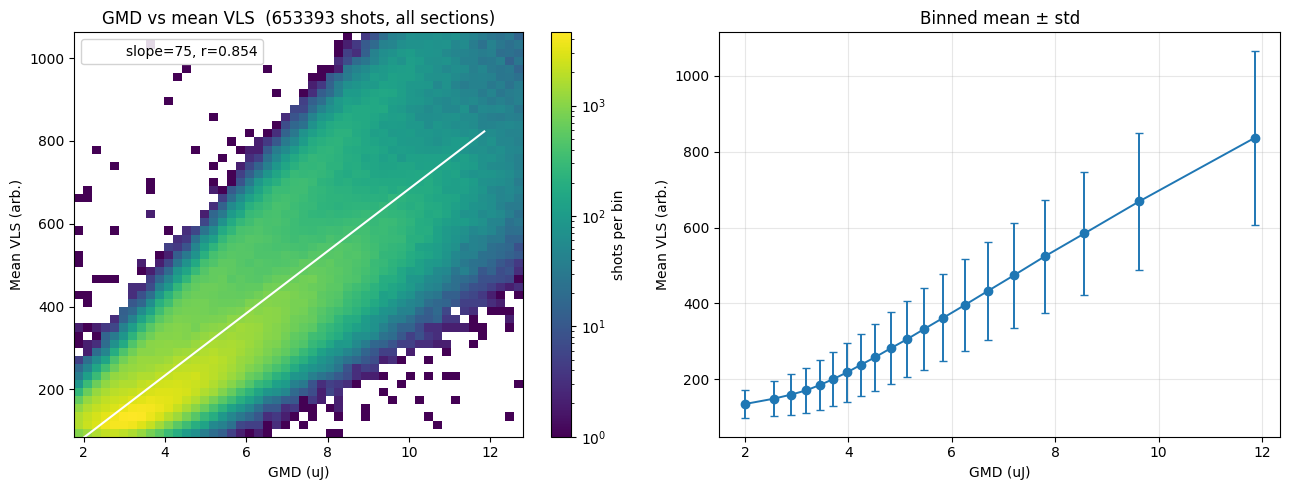

In [133]:
y_vls_mean = A_valid.mean(axis=1)

bin_edges_b = np.percentile(g_valid, np.linspace(0, 100, 21))
bin_idx_b   = np.clip(np.digitize(g_valid, bin_edges_b) - 1, 0, len(bin_edges_b) - 2)
x_mean_b = np.array([np.nanmean(g_valid[bin_idx_b == b])    if np.any(bin_idx_b == b) else np.nan
                     for b in range(len(bin_edges_b) - 1)])
y_mean_b = np.array([np.nanmean(y_vls_mean[bin_idx_b == b]) if np.any(bin_idx_b == b) else np.nan
                     for b in range(len(bin_edges_b) - 1)])
y_std_b  = np.array([np.nanstd(y_vls_mean[bin_idx_b == b])  if np.any(bin_idx_b == b) else np.nan
                     for b in range(len(bin_edges_b) - 1)])

r = float(np.corrcoef(g_valid, y_vls_mean)[0, 1])
slope, intercept = np.polyfit(g_valid, y_vls_mean, 1)
xl = np.linspace(np.nanmin(x_mean_b), np.nanmax(x_mean_b), 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
h = ax1.hist2d(
    g_valid, y_vls_mean,
    bins=[np.linspace(np.percentile(g_valid, 1),    np.percentile(g_valid, 99),    51),
          np.linspace(np.percentile(y_vls_mean, 1), np.percentile(y_vls_mean, 99), 51)],
    cmap='viridis', cmin=1, norm=mcolors.LogNorm(),
)
fig.colorbar(h[3], ax=ax1, label='shots per bin')
ax1.plot(xl, slope * xl + intercept, color='white', lw=1.5,
         label=f'slope={slope:.3g}, r={r:.3f}')
ax1.set_xlabel('GMD (uJ)')
ax1.set_ylabel('Mean VLS (arb.)')
ax1.set_title(f'GMD vs mean VLS  ({len(g_valid)} shots, all sections)')
ax1.legend(loc='upper left', framealpha=0.85)

ax2.errorbar(x_mean_b, y_mean_b, yerr=y_std_b, fmt='o-', color='tab:blue',
             capsize=3, lw=1.4)
ax2.set_xlabel('GMD (uJ)')
ax2.set_ylabel('Mean VLS (arb.)')
ax2.set_title('Binned mean ± std')
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## GMD binning per proxy energy

Accumulate sums over shots grouped by (proxy_pixel, GMD bin).

In [134]:
N_GMD = len(GMD_EDGES) - 1

A_sum     = np.zeros((N_proxy_E, N_GMD, n_pixels), dtype=np.float64)
G_sum     = np.zeros((N_proxy_E, N_GMD),           dtype=np.float64)
n_per_bin = np.zeros((N_proxy_E, N_GMD),           dtype=np.int64)

gmd_bins = np.digitize(g_valid, GMD_EDGES) - 1
in_range = (gmd_bins >= 0) & (gmd_bins < N_GMD)

pe_ir = proxy_idx[in_range]
gb_ir = gmd_bins[in_range]
G_ir  = g_valid[in_range]
A_ir  = A_valid[in_range]

np.add.at(n_per_bin, (pe_ir, gb_ir), 1)
np.add.at(G_sum,     (pe_ir, gb_ir), G_ir)
np.add.at(A_sum,     (pe_ir, gb_ir), A_ir)   # vectorised over pixels — no pixel loop needed

safe_n = np.where(n_per_bin > 0, n_per_bin, 1).astype(np.float64)
G_mean = np.where(n_per_bin > 0, G_sum / safe_n, np.nan)
A_mean = np.where(n_per_bin[:, :, None] > 0, A_sum / safe_n[:, :, None], np.nan)

print(f'unique proxy energies (pixels): {N_proxy_E}')
print(f'total shots binned            : {int(n_per_bin.sum())}')
print(f'A_mean shape                  : {A_mean.shape}')

unique proxy energies (pixels): 66
total shots binned            : 646834
A_mean shape                  : (66, 4, 200)


## Shot counts per (proxy energy, GMD bin)

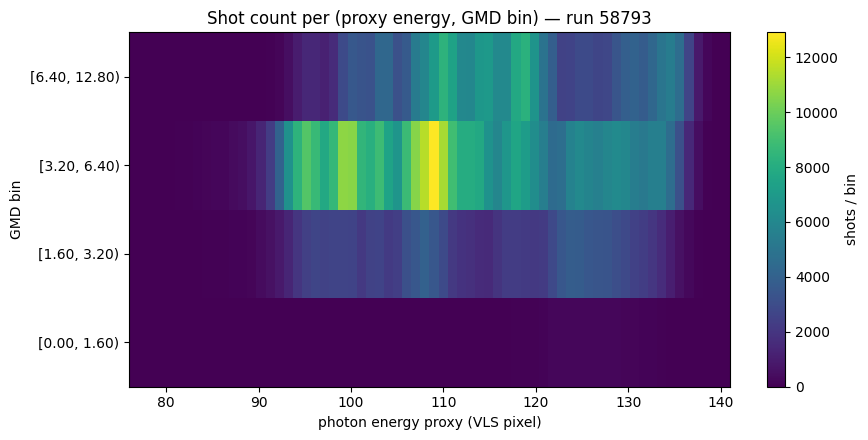

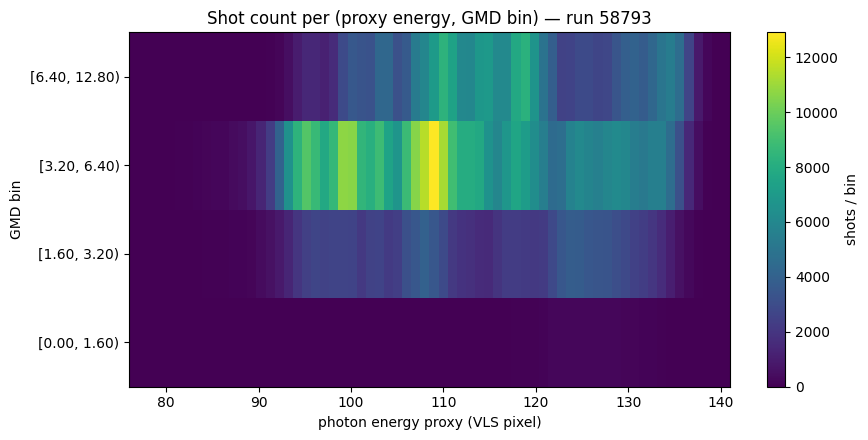

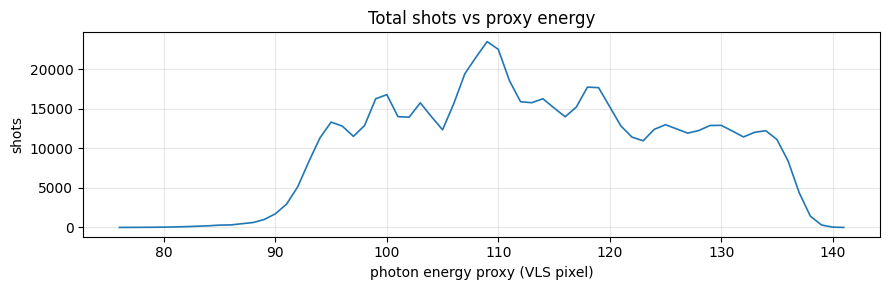

In [135]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(
    n_per_bin.T,
    aspect='auto', origin='lower',
    extent=[proxy_energies[0], proxy_energies[-1], 0, N_GMD],
    cmap='viridis',
)
fig.colorbar(im, ax=ax, label='shots / bin')
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('GMD bin')
ax.set_yticks(np.arange(N_GMD) + 0.5)
ax.set_yticklabels([f'[{GMD_EDGES[i]:.2f}, {GMD_EDGES[i+1]:.2f})' for i in range(N_GMD)])
ax.set_title(f'Shot count per (proxy energy, GMD bin) — run {RUN_NO}')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.plot(proxy_energies, n_per_bin.sum(axis=1), color='tab:blue', lw=1.2)
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('shots')
ax.set_title('Total shots vs proxy energy')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Mean GMD per (proxy energy, GMD bin)

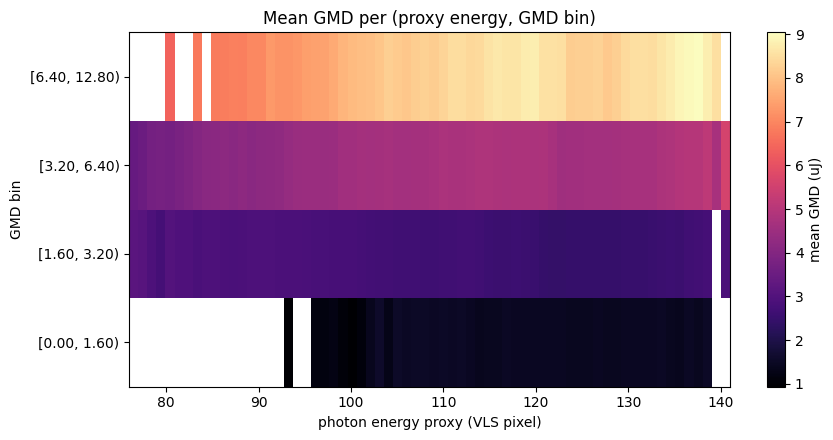

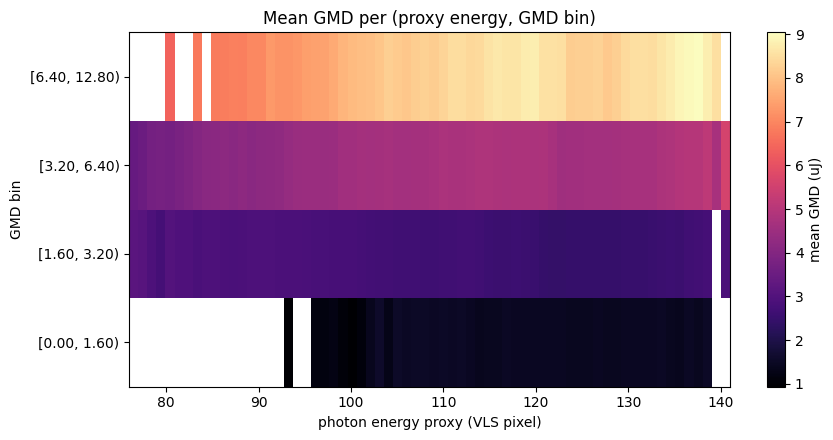

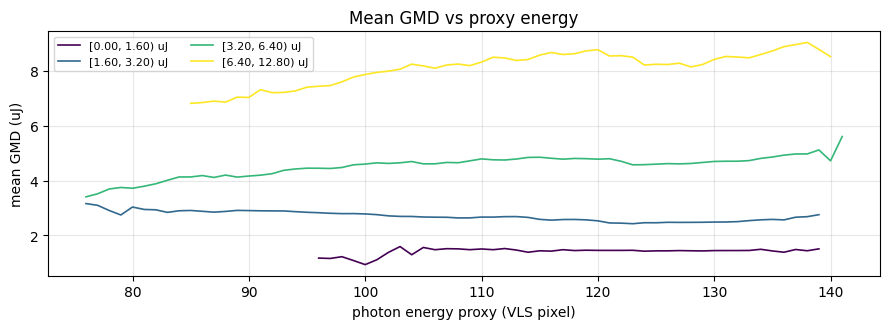

In [136]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(
    G_mean.T,
    aspect='auto', origin='lower',
    extent=[proxy_energies[0], proxy_energies[-1], 0, N_GMD],
    cmap='magma',
)
fig.colorbar(im, ax=ax, label='mean GMD (uJ)')
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('GMD bin')
ax.set_yticks(np.arange(N_GMD) + 0.5)
ax.set_yticklabels([f'[{GMD_EDGES[i]:.2f}, {GMD_EDGES[i+1]:.2f})' for i in range(N_GMD)])
ax.set_title('Mean GMD per (proxy energy, GMD bin)')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.4))
cmap = plt.get_cmap('viridis')
for g in range(N_GMD):
    ax.plot(proxy_energies, G_mean[:, g], lw=1.2,
            color=cmap(g / max(N_GMD - 1, 1)),
            label=f'[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ')
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('mean GMD (uJ)')
ax.set_title('Mean GMD vs proxy energy')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Mean VLS spectrum per (proxy energy, GMD bin)

One panel per GMD bin. Each panel is a heatmap of
**proxy energy (rows) × VLS pixel (columns)**.

/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_2771/1569391102.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_2771/1569391102.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


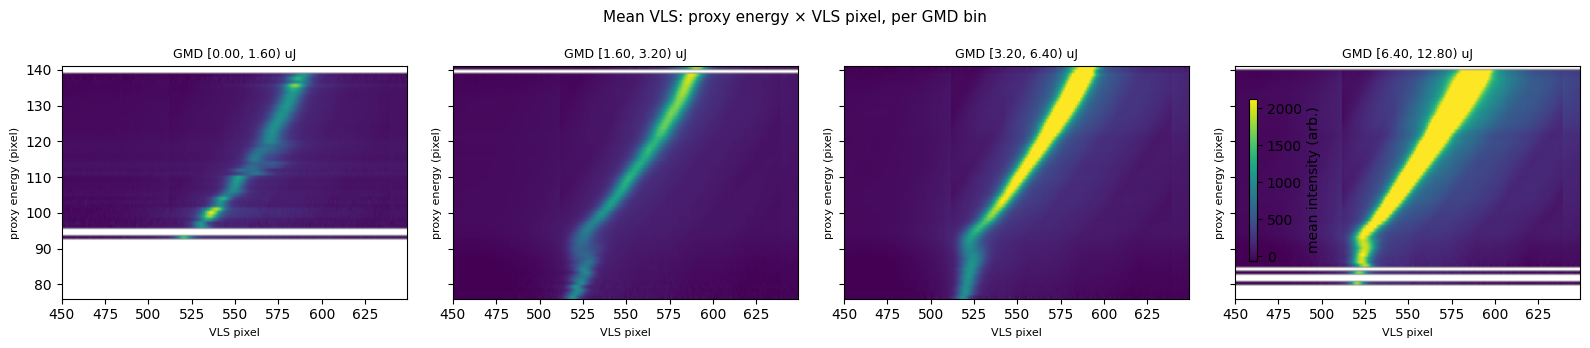

In [137]:
finite_mask = np.isfinite(A_mean)
vmin, vmax = (np.nanpercentile(A_mean[finite_mask], [2, 98])
              if finite_mask.any() else (0.0, 1.0))

ncols = min(N_GMD, 4)
nrows = int(np.ceil(N_GMD / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4.0 * ncols, 3.5 * nrows),
                         sharex=True, sharey=True, squeeze=False)
im = None
for g in range(nrows * ncols):
    r, c = divmod(g, ncols)
    ax = axes[r][c]
    if g >= N_GMD:
        ax.axis('off')
        continue
    im = ax.imshow(
        A_mean[:, g, :],             # (N_proxy_E, n_pixels)
        aspect='auto', origin='lower',
        extent=[vls_pixels[0], vls_pixels[-1],
                proxy_energies[0], proxy_energies[-1]],
        cmap='viridis', vmin=vmin, vmax=vmax,
    )
    ax.set_title(f'GMD [{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ', fontsize=9)
    ax.set_xlabel('VLS pixel', fontsize=8)
    ax.set_ylabel('proxy energy (pixel)', fontsize=8)
if im is not None:
    fig.colorbar(im, ax=axes, shrink=0.6, label='mean intensity (arb.)')
fig.suptitle('Mean VLS: proxy energy × VLS pixel, per GMD bin', fontsize=11)
fig.tight_layout()
plt.show()

## XAS(E_proxy) per GMD bin

`XAS = <GMD> / sum_pixels(<VLS>)` — one line per GMD bin,
plotted against the proxy pixel energy.

In [138]:
vls_sum = np.nansum(A_mean, axis=2)  # (N_proxy_E, N_GMD)
with np.errstate(divide='ignore', invalid='ignore'):
    xas = G_mean / vls_sum  # (N_proxy_E, N_GMD)
fig = go.Figure()
cmap = plt.get_cmap('viridis')
for g in range(N_GMD):
    color = mcolors.to_hex(cmap(g / max(N_GMD - 1, 1)))
    fig.add_trace(
        go.Scatter(
            x=proxy_energies,
            y=xas[:, g],
            mode='lines',
            name=f'[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ',
            line=dict(width=2, color=color),
            hovertemplate=(
                'GMD bin=%{fullData.name}<br>'
                'proxy pixel=%{x}<br>'
                'XAS=%{y}<extra></extra>'
            ),
        )
    )
fig.update_layout(
    title=f'Run {RUN_NO}: XAS(E_proxy) per GMD bin',
    xaxis_title='photon energy proxy (VLS pixel)',
    yaxis_title='XAS = <GMD> / sum_pix(<VLS>)',
    template='plotly_white',
    height=500,
    legend=dict(title='GMD bin'),
)
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

In [139]:
from IPython.display import HTML, display
N_SHOW = 20
SHOT_STRIDE = max(1, len(A_valid) // N_SHOW)  # uniform stride
shot_indices = np.arange(0, len(A_valid), SHOT_STRIDE)[:N_SHOW]
vls_pixel_rel = np.arange(n_pixels)
fig = go.Figure()
for k, idx in enumerate(shot_indices):
    fig.add_trace(
        go.Scatter(
            x=vls_pixel_rel,
            y=A_valid[idx],
            mode='lines',
            name=(
                f'shot {idx} | E_nom={nominal_energy_valid[idx]:.2f} eV | '
                f'px={proxy_pixel[idx]} | GMD={g_valid[idx]:.2f} uJ'
            ),
            line=dict(width=2),
            opacity=0.8,
            hovertemplate=(
                'shot=%{fullData.name}<br>'
                'VLS pixel (relative)=%{x}<br>'
                'intensity=%{y}<extra></extra>'
            ),
        )
    )
fig.update_layout(
    xaxis_title='VLS pixel (relative)',
    yaxis_title='intensity (arb., bg-subtracted)',
    template='plotly_white',
    height=700,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='left',
        x=0.0,
        font=dict(size=10),
    ),
    margin=dict(t=160),
)
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))
